###AIRO Linear Regression Advanced Example
Student Factors vs. Exam Grade

Created by Caden Wondell

Step 1: Mount to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 2: Import Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

#Some data is strings it must be converted into a number for linear regression to work
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

Step 3: Load and Preview the Dataset

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/Colab_Notebooks/AIRO_CLUB/Examples/Exam_Score_Prediction.csv"
)
data.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


Step 4: Select the Feature and Target

In [ ]:
# Features: what we give the model
X = data[[
    "study_hours",
    "class_attendance",
    "internet_access",
    "sleep_hours",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]]

# Target: what we want the model to predict
y = data["exam_score"]

Step 5: Split the Data into Training and Testing Sets

In [ ]:
#Split data into Training and Testing datasets, Training is 80%, Testing is 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 6: Convert categorical features into numbers

In [ ]:
# Identify categorical features
categorical_features = [
    "internet_access",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]

# Convert categorical features into numbers
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

Step 7: Create and Train the Linear Regression Model

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

model.fit(X_train, y_train) #Train the model

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['internet_access',
                                                   'sleep_quality',
                                                   'study_method',
                                                   'facility_rating',
                                                   'exam_difficulty'])])),
                ('regression', LinearRegression())])

Step 8: Make Predictions

In [ ]:
predictions = model.predict(X_test) #Make predictions

predictions[:5] #Show the first 5 predictions

array([ 36.7222309 ,  80.10408689,  54.32051123, 102.24059811,
        80.64138178])

Step 9: Compare Predicted and Actual Scores

In [ ]:
results = X_test.copy()
results["Actual Score"] = y_test
results["Predicted Score"] = predictions

results.head(5) #Compare Predictions vs Real scores

,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,Actual Score,Predicted Score
10650,2.01,48.2,yes,4.9,poor,mixed,medium,easy,31.1,36.722231
2041,6.56,45.9,no,4.4,good,coaching,high,hard,81.6,80.104087
8668,4.27,41.0,yes,8.9,good,self-study,low,moderate,68.0,54.320511
1114,7.28,91.7,yes,5.9,good,coaching,high,easy,100.0,102.240598
13902,7.13,64.3,yes,9.5,good,online videos,low,moderate,84.8,80.641382


Step 10: Evaluate the Model

In [ ]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", round(mae, 2)) #The lower the score the better the prediction

Mean Absolute Error: 7.86


Step 11: Visualize the Linear Regression Model

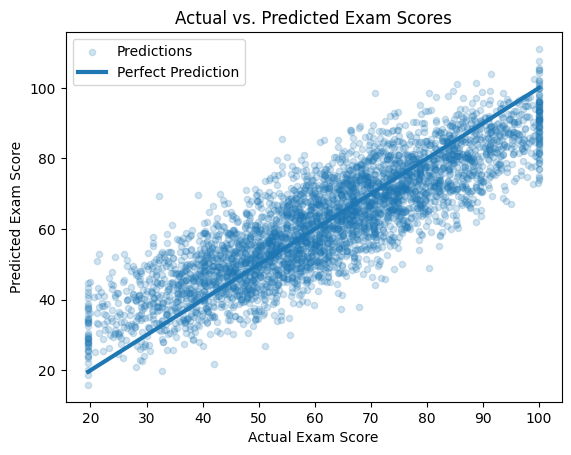

In [ ]:
plt.scatter(
    y_test,
    predictions,
    alpha=0.2,
    s=20,
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=3,
    label="Perfect Prediction"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs. Predicted Exam Scores")
plt.legend()

plt.show()

Step 12: Make a Prediction for a New Student

In [ ]:
new_student = pd.DataFrame({

   "study_hours": [7.91], # Dataset range: 0.08 - 7.91 hours

    "class_attendance": [90], # Dataset range: 40.6 - 99.4 percent

    "internet_access": ["yes"], # yes, no

    "sleep_hours": [7], # Dataset range: 4.1 - 9.9 hours

    "sleep_quality": ["average"], # poor, average, good

    "study_method": ["coaching"], # coaching, group study, mixed, online videos, self-study

    "facility_rating": ["high"], # low, medium, high

    "exam_difficulty": ["moderate"] # easy, moderate, hard

})

predicted_score = model.predict(new_student)

print("Predicted Exam Score:", round(predicted_score[0], 2))

Predicted Exam Score: 102.63
